# Task 2: Imitation Learning

## Setup Code / Packages
If you are running the code locally follow the instructions [here](../docs/setup.md).

If you are using Google Colab make sure to run the two cells below to install all dependencies and enable headless rendering. You will also need to upload your xml file to the assets folder.

In [2]:
# Core sim stack
%pip install "gymnasium[mujoco]==0.29.1" numpy scipy matplotlib imageio imageio-ffmpeg
# Optional CPU-only torch wheel:
%pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
os.environ["MUJOCO_GL"] = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"

## Using Gymnasium
No problems are assigned here, but understanding the code APIs/interfaces and functionalities are important.

### Gymnasium Basics
The Gymnasium package is a standardized API for creating and interacting with simulation environments. 

<img src="../assets/media/gym_loop.png" alt="agent-environment loop" width="500"/>

Gymnasium defines the agent-environment loop — a simple interface where an agent takes actions and receives observations, rewards, and termination signals from an environment. This loop forms the foundation for reinforcement learning (RL) and allows us to easily manipulate the simulator.

**Why We Use Gymnasium**

Gymnasium acts as a common interface layer between learning algorithms and simulation environments. It provides:
- A uniform API (reset(), step(), observation, reward, done, info) 
- Integration with RL algorithm libraries (e.g., Stable-Baselines3, CleanRL).
- Rendering and debugging utilities for visualization and evaluation.


In this task, you will use Gymnasium as the primary API to interface with the simulator to :
- Collect trajectory data for imitation learning.
- Evaluate and deploy trained policies.

Read their documentation [here](https://gymnasium.farama.org/).


## Part 0: Creating a Standardized Environment with Gymnasium
In this part, you will implement the `TrajEnv` class to wrap a MuJoCo simulation in a Gymnasium interface.

Your task is to decide which observations are useful as states in a behavior cloning setting. You will also implement the `is_grasped` property to define when the robot has successfully grasped the object and the `terminated` property to specify when the cube is in the bin. The `reset_model` method should randomize initial arm and object positions to encourage generalization.

You should step through Gymnasium functions like `do_simulation` and `set_state` to see how to control the simulator.

In [9]:
from scipy.spatial.transform import Rotation as R
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box
import numpy as np
import mujoco
import os

XML_PATH = os.path.abspath("/home/kaw118/simulation/assets/descriptions/DropCubeInBinEnv.xml")

class TrajEnv(MujocoEnv):
    metadata = {"render_modes": ["human", "rgb_array", "depth_array"]}

    def __init__(self, xml_file: str, frame_skip: int = 5, **kwargs):
        # TODO: Define the observation space and store any useful state variables.
        observation_space = Box(
            # shape: qpos=16, qvel=15, gripper=3, bin=3
            low=-np.inf, high=np.inf, shape=(37,), dtype=np.float32  # TODO: set correct shape
        )

        super().__init__(
            xml_file,
            frame_skip,
            observation_space=observation_space,
            **kwargs,
        )

        self.panda_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_BODY, 'panda_arm')
        

    
    @property
    def is_grasped(self):
        # TODO: Implement a condition to determine if the object
        # is grasped. Could use distance between gripper and object, contact forces, etc.

        cube_pos = self.data.body("cube").xpos
        hand_pos = self.data.body("hand").xpos

        distance = np.linalg.norm(cube_pos - hand_pos)
        home_cube_z = self.model.keyframe("home").qpos[11]

        return bool(distance < 0.12 and cube_pos[2] > home_cube_z + 0.02)



    @property
    def terminated(self):
        # TODO: Define the termination condition for an episode.
        
        cube_pos = self.data.body("cube").xpos
        bin_pos = self.data.body("simpleWoodBin").xpos
        dx, dy, dz = cube_pos - bin_pos

        return bool(abs(dx) < 0.02 and abs(dy) < 0.02 and 0.025 < abs(dz) < 0.05)

    def _get_obs(self):
        # TODO: Return the observations selected for the environment state
        # Example: joint positions, velocities, end-effector pose, object positions

        return np.concatenate((
            self.data.qpos,
            self.data.qvel,
            self.data.body("hand").xpos,
            self.data.body("simpleWoodBin").xpos,
        )).astype(np.float32)

    def step(self, action: np.ndarray) -> tuple[np.ndarray, bool, bool]:
        # DO NOT MODIFY THIS FUNCTION
        self.do_simulation(action, self.frame_skip)
        obs = self._get_obs()
        terminated = self.terminated

        if self.render_mode == "human":
            self.render()

        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        return obs, None, terminated, False, None

    def reset_model(self):
        self.default_qpos = np.array(
                self.model.keyframe('home').qpos,
                dtype=np.float32
            )

        qpos = self.default_qpos.copy()
        qvel = np.zeros(self.model.nv)

        # TODO: Randomize initial positions for the arm (9 joints) and objects
        # to create diverse starting conditions. Ensure valid states and objects are not overlapping.
        
        qpos[9:11] += self.np_random.uniform(-0.02, 0.02, size=2)
        qpos[:7] += self.np_random.uniform(-0.01, 0.01, size=7)
        

        self.set_state(qpos, qvel)
        return self._get_obs()



To understand what is happening in the environment, you can call `env.render()` to visualize it.  
Since we set `render_mode="rgb_array"`, `env.render()` will return an RGB array that can be displayed.  


> **Note:** If the default view of the environment is not ideal, you may need to adjust the camera.  
> You can do this by defining a camera in your Mujoco XML file and then passing its name as a kwarg to the `TrajEnv` constructor via the `camera_name` argument.


If you are on colab you can render the environment like so. If you are running MuJoCo locally you can use `render_mode="human"` to display viewing window.


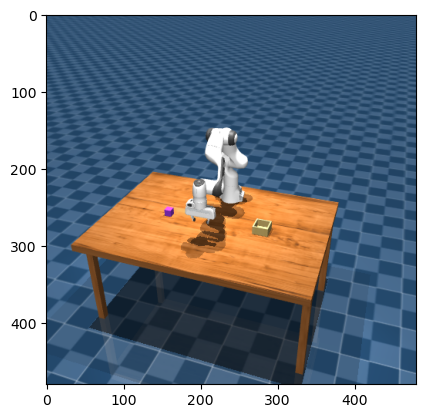

In [10]:
from gymnasium.wrappers import TimeLimit
import matplotlib.pyplot as plt

env = TrajEnv(XML_PATH, 20, render_mode='rgb_array', camera_name="fixed")
env = TimeLimit(env, 100)
env.reset()
image = env.render() 
plt.imshow(image)

With these core functionalities we can build the basic interaction loop that consists of a reset followed by steps until terminated or truncated is True. We can also record a video as well.

In [11]:
obs, _ = env.reset()
done = False
images = [env.render()]
# keep taking steps until either we terminated or truncate
while not done:
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    images.append(env.render())
    done = terminated or truncated

In [12]:
from IPython.display import Video
import imageio

frames = images 
frames = [frame.astype(np.uint8) for frame in frames]   

# Write video to file
video_path = "output_video.mp4"
with imageio.get_writer(video_path, fps=20) as writer:
    for frame in frames:
        writer.append_data(frame)

# Display video in notebook
Video(video_path, embed=True)

We will now try and control the robot to grasp the cube, pick it up, and drop it in the wooden bin. 

The following code sets up a motion planning library for you and saves some useful variables. 
- `planner`: The planner objects uses screw motion planning.
- `panda_hand_tcp`: The panda hand tool center point "link", which gives the current pose of the link we are controlling via the motion planning library. This is the point in the middle between the two panda arm grippers.
- `cube`: The cube object, which you can use to acccess its pose.
- `bin`: The bin object.

The motion planner setup will generate a sequence joint position actions for all the joints excluding the gripper. The gripper actions you can manually pick (can range from 0 to 255). 

In [13]:
import mplib
import os

env = TrajEnv(
    xml_file=XML_PATH, 
    frame_skip=20,
    render_mode="rgb_array"
    
)
env.reset(seed=42)

link_names = [
    'panda_link0','panda_link1','panda_link2','panda_link3','panda_link4',
    'panda_link5','panda_link6','panda_link7','panda_link8','panda_hand',
    'panda_hand_tcp','panda_leftfinger','panda_rightfinger',
    'panda_leftfinger_pad','panda_rightfinger_pad'
]
joint_names = [
    'panda_joint1','panda_joint2','panda_joint3','panda_joint4',
    'panda_joint5','panda_joint6','panda_joint7','panda_finger_joint1','panda_finger_joint2'
]

planner = mplib.Planner(
    urdf=os.path.abspath("../assets/descriptions/panda/urdf/panda.urdf"),
    srdf=os.path.abspath("../assets/descriptions/panda/urdf/panda.srdf"),
    user_link_names=link_names,
    user_joint_names=joint_names,
    move_group="panda_hand_tcp",
    joint_vel_limits=np.ones(7) * 0.8,
    joint_acc_limits=np.ones(7) * 0.8,
)

# this sets the planner object up such that you can plan with poses in the world frame, which is the default frame of all pose data
# in our simulator
planner.set_base_pose(
    mplib.Pose(
        p=env.data.xpos[env.panda_id].copy(),
        q=env.data.xquat[env.panda_id].copy(),
    )
)

**Notes for this task**

The goal is to use the motion planner to pick up the cube and drop it into the bin.

- You will need to access object positions and orientations from the simulator (env.data.xpos, env.data.xquat, etc.).
- The motion planner requires a target pose (7,) for the robot hand (position + quaternion) and the current joint configuration (qpos). Both are expressed in the world frame.
- Plan a trajectory to a consistent grasp pose above the cube, execute it while keeping the gripper open, then move down and close the gripper to pick up the cube.    
- Finally, open the gripper to release the cube into the bin.

The planner may fail if the pose is unreachable, collides with the environment, or the solver does not converge. This is expected—adjust poses or retry if needed.

In [14]:
def pick_cube_solution(env, episode_data=None):
    cube_pos = env.unwrapped.data.body("cube").xpos.copy()
    target_quat = env.unwrapped.data.body("hand").xquat.copy()

    align = np.array([0.010, 0.004, 0.0]) # compensation for between the midpoint of gripper and center of cube/bin

    above_cube = cube_pos + align + np.array([0.0, 0.0, 0.15])
    grasp_height = cube_pos + align + np.array([0.0, 0.0, 0.01])
    lifted = cube_pos + align + np.array([0.0, 0.0, 0.20])

    if not move_hand(env, above_cube, target_quat, 255, episode_data=episode_data):
        return False

    if not move_hand(env, grasp_height, target_quat, 255, episode_data=episode_data):
        return False
    
    open_and_close_gripper(env, 0, steps=20, episode_data=episode_data)

    if not move_hand(env, lifted, target_quat, 0, episode_data=episode_data):
        return False

    bin_pos = env.unwrapped.data.body("simpleWoodBin").xpos.copy()
    above_bin = bin_pos + align + np.array([0.0, 0.0, 0.20])

    if not move_hand(env, above_bin, target_quat, 0, episode_data=episode_data):
        return False

    open_and_close_gripper(env, 255, steps=70, episode_data=episode_data)
    print("Cube after release:", env.unwrapped.data.body("cube").xpos.copy())
    print("In bin:", env.unwrapped.terminated)
    return env.unwrapped.terminated


def move_hand(env, target_pos, target_quat, gripper_command, episode_data=None):
    result = planner.plan_screw(
        goal_pose=mplib.Pose(p=target_pos, q=target_quat),
        current_qpos=env.unwrapped.data.qpos[:7].copy(),
        time_step=env.unwrapped.dt,
    )

    if result["status"] != "Success":
        print("Planner failed:", result["status"])
        return False

    for arm_pos in result["position"]:
        action = np.concatenate([arm_pos, [gripper_command]])
        step_and_record(env, action, episode_data)
    return True


def open_and_close_gripper(env, gripper_command, steps=20, episode_data=None):
    for _ in range(steps):
        arm_pos = env.unwrapped.data.qpos[:7].copy()
        action = np.concatenate([arm_pos, [gripper_command]])
        step_and_record(env, action, episode_data)


def step_and_record(env, action, episode_data=None):
    action = np.asarray(action, dtype=np.float32)
    if episode_data is not None:
        obs = env.unwrapped._get_obs().copy()
        episode_data.append((obs, action.copy()))
    return env.step(action)

## Part 1: Collect your Imitation Learning Dataset


Now that you’ve used the motion planner to complete a single pick-and-place sequence, the next step is to repeat this process many times to collect a dataset for imitation learning.

In imitation learning, the dataset is made of trajectories—sequences of state-action pairs showing how an expert (in this case, the motion planner) solves the task. Each trajectory will later be used to train a policy that imitates this behavior.

>**Tip**: Standardizing the orientation and approach of the gripper will help the robot pick up the cube in the same way each time, resulting in a more reliable model.


In [8]:
import pickle

env = TrajEnv(
    xml_file=XML_PATH, 
    frame_skip=20,
)

trajectories = []

EPISODES = 60
TARGET_SUCCESSES = 20
success_count = 0

for i in range(EPISODES):
    env.reset(seed=i)
    
    # this sets the planner object up such that you can plan with poses in the world frame.
    planner.set_base_pose(mplib.Pose(
        p=env.data.xpos[env.panda_id].copy(),
        q=env.data.xquat[env.panda_id].copy(),
    ))
    episode_data = []

    

    result = pick_cube_solution(env, episode_data)


    if result:
        trajectories.append(episode_data)
        print(f"Episode {i} completed successfully.")
        success_count += 1

        if success_count >= TARGET_SUCCESSES:
            print(f"Success rate: {success_count / (i + 1)}")
            break
    
    
# ===== Save dataset =====
with open("pick_place_dataset.pkl", "wb") as f:
    pickle.dump(trajectories, f)

print(f"Total trajectories: {len(trajectories)}")
env.close()

Cube after release: [-0.36308917  0.01397343  0.79478449]
In bin: True
Episode 0 completed successfully.
Cube after release: [-0.31348017 -0.0342795   0.84492668]
In bin: False
Cube after release: [-0.31593055 -0.03385877  0.84492023]
In bin: False
Cube after release: [-0.36629205 -0.00696458  0.79478449]
In bin: True
Episode 3 completed successfully.
Cube after release: [-0.36407157 -0.01512252  0.79478443]
In bin: True
Episode 4 completed successfully.
Cube after release: [-0.2643688  -0.05074168  0.78478448]
In bin: False
Cube after release: [-0.3606269   0.00905964  0.80466217]
In bin: True
Episode 6 completed successfully.
Cube after release: [-0.26652665 -0.05087959  0.78478447]
In bin: False
Cube after release: [-0.26480853 -0.05057207  0.78478447]
In bin: False
Cube after release: [-0.33611011  0.00132831  0.79478449]
In bin: True
Episode 9 completed successfully.
Cube after release: [-0.33190006 -0.01354058  0.79478449]
In bin: True
Episode 10 completed successfully.
Cube afte

## Part 2: Create Behavior Cloning Dataset

Using the trajectory data you have collected in the previous task, complete the `TrajectoryDataset` class to feed your model. 

>**NOTE**: The model learns to map states to actions, so the order of the data is not important. You can flatten all episodes and sample from any step freely.

In [ ]:
import pickle
import torch
from torch.utils.data import Dataset


class TrajectoryDataset(Dataset):
    def __init__(self, data):
        pairs = [pair for episode in data for pair in episode]
        if not pairs:
            raise ValueError("Dataset has no state-action pairs")

        self.observations = torch.from_numpy(np.stack([obs for obs, action in pairs]).astype(np.float32))
        actions = np.stack([action for obs, action in pairs]).astype(np.float32)
        actions[:, -1] /= 255.0
        self.actions = torch.from_numpy(actions)

    def __len__(self):
        return len(self.observations)

    def __getitem__(self, idx):
        #This should return observation idx and action idx
        return self.observations[idx], self.actions[idx]


dataset_file = "pick_place_dataset.pkl"
with open(dataset_file, "rb") as f:
    data = pickle.load(f)
dataset = TrajectoryDataset(data)

## Part 3: Define the Policy Network

In this step, you will implement a behavior cloning policy network. The goal of this network is to learn to map observations (states) to actions by imitating the trajectories you collected earlier. 

**NOTE**: See [tips](tips.md) for guidance on designing your network architecture and BC overview.

In [4]:
import torch.nn as nn

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        #TODO: Define the network architecture
        # Start with a basic MLP and experiment with different architectures
        
        self.backbone = nn.Sequential(
            nn.Linear(37, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        self.mean_head = nn.Linear(128, 8)
        self.log_std_head = nn.Linear(128, 8)


    def forward(self, obs):
        features = self.backbone(obs)
        mean = self.mean_head(features)
        log_std = self.log_std_head(features).clamp(-5, 2)
        return mean, log_std

In [5]:
import gymnasium as gym
import torch.nn as nn
import numpy as np
import torch

def eval_policy(eval_env: gym.Env, actor: nn.Module, num_episodes: int = 5):
    success = 0
    actor_device = next(actor.parameters()).device

    for ep in range(num_episodes):
        obs, _ = eval_env.reset()
        terminated, truncated = False, False
        
        while not (terminated or truncated):
            with torch.no_grad():
                action, _ = actor(torch.as_tensor(obs, dtype=torch.float32, device=actor_device))
                
            action = action.cpu().numpy()
            action[-1] = np.clip(action[-1], 0.0, 1.0) * 255.0
            action = np.clip(action, eval_env.action_space.low, eval_env.action_space.high)
            obs, _, terminated, truncated, _ = eval_env.step(action)

        if terminated:
            success += 1
        
        print(f"Episode {ep+1}: Success={terminated}")
    return success / num_episodes

## Part 4: Training Loop
You will train the neural network policy to imitate expert behavior.

We’ve provided an `eval_policy` function to test your actor in simulation. It runs several episodes and reports a success rate, so you can track how well your policy performs as training progresses.

In [6]:
from torch.utils.data import DataLoader
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)

actor = Actor().to(device)

batch_size = 1024
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

lr = 3e-5
epochs = 100

def nll_loss(actor: nn.Module, obs: torch.Tensor, expert_actions: torch.Tensor):
    mean, log_std = actor(obs)
    std = log_std.exp()
    dist = torch.distributions.Normal(mean, std)
    log_prob = dist.log_prob(expert_actions).sum(-1)   #sum over action dims
    loss = -log_prob.mean()
    return loss

# TODO: Write the training loop
# Train the actor policy to predict the actions in the dataset.
# Make sure to run the eval_policy function every once in a while to track training progress
# and save your best policy checkpoint to be loaded later for evaluation. 
# If you are confident in your model, sometimes a different seed can work. 
# Training time depends on number of samples and number of epochs, but should not take more than 10 minutes on google colab.

optimizer = torch.optim.Adam(actor.parameters(), lr=lr, foreach=False)

for epoch in range(1, epochs + 1):
    actor.train()
    total_loss = 0.0

    for obs, expert_actions in dataloader:
        obs = obs.to(device)
        expert_actions = expert_actions.to(device)

        optimizer.zero_grad()
        loss = nll_loss(actor, obs, expert_actions)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(obs)

    print(f"Epoch {epoch}: loss={total_loss / len(dataset):.4f}", flush=True)


Epoch 1: loss=13.4897
Epoch 2: loss=13.2341
Epoch 3: loss=12.9933
Epoch 4: loss=12.7631
Epoch 5: loss=12.5400
Epoch 6: loss=12.3199
Epoch 7: loss=12.1007
Epoch 8: loss=11.8812
Epoch 9: loss=11.6595
Epoch 10: loss=11.4350
Epoch 11: loss=11.2102
Epoch 12: loss=10.9868
Epoch 13: loss=10.7628
Epoch 14: loss=10.5382
Epoch 15: loss=10.3152
Epoch 16: loss=10.0943
Epoch 17: loss=9.8763
Epoch 18: loss=9.6607
Epoch 19: loss=9.4463
Epoch 20: loss=9.2338
Epoch 21: loss=9.0236
Epoch 22: loss=8.8155
Epoch 23: loss=8.6080
Epoch 24: loss=8.3989
Epoch 25: loss=8.1880
Epoch 26: loss=7.9747
Epoch 27: loss=7.7579
Epoch 28: loss=7.5399
Epoch 29: loss=7.3237
Epoch 30: loss=7.1104
Epoch 31: loss=6.8973
Epoch 32: loss=6.6844
Epoch 33: loss=6.4726
Epoch 34: loss=6.2620
Epoch 35: loss=6.0506
Epoch 36: loss=5.8361
Epoch 37: loss=5.6200
Epoch 38: loss=5.4029
Epoch 39: loss=5.1814
Epoch 40: loss=4.9541
Epoch 41: loss=4.7181
Epoch 42: loss=4.4748
Epoch 43: loss=4.2293
Epoch 44: loss=3.9693
Epoch 45: loss=3.6984
Epo

## Part 5: Evaluate in Simulator
Time to evaluate your model. You may notice that it doesn’t succeed very often and may behave unpredictably or erratically. 

Can you think about why this might happen?

In [18]:
import torch
import numpy as np
from gymnasium.wrappers import RecordVideo, TimeLimit


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)

eval_env = TimeLimit(
    TrajEnv(XML_PATH, 20, render_mode="rgb_array"),
    max_episode_steps=800,
)
eval_env = RecordVideo(
    eval_env,
    "videos",                       # folder to save videos
    episode_trigger=lambda e: True,  # record every episode
    name_prefix="bc-model"
    )
actor = Actor()

state_dict = torch.load("bc_actor.pt", map_location="cpu", weights_only=True)
actor.load_state_dict(state_dict)

#Evaluation
eval_policy(eval_env, actor, 5)
eval_env.close()

Moviepy - Building video /home/kaw118/simulation/task2/videos/bc-model-episode-0.mp4.
Moviepy - Writing video /home/kaw118/simulation/task2/videos/bc-model-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /home/kaw118/simulation/task2/videos/bc-model-episode-0.mp4
Episode 1: Success=False
Moviepy - Building video /home/kaw118/simulation/task2/videos/bc-model-episode-1.mp4.
Moviepy - Writing video /home/kaw118/simulation/task2/videos/bc-model-episode-1.mp4



Moviepy - Done !
Moviepy - video ready /home/kaw118/simulation/task2/videos/bc-model-episode-1.mp4
Episode 2: Success=False
Moviepy - Building video /home/kaw118/simulation/task2/videos/bc-model-episode-2.mp4.
Moviepy - Writing video /home/kaw118/simulation/task2/videos/bc-model-episode-2.mp4



Moviepy - Done !
Moviepy - video ready /home/kaw118/simulation/task2/videos/bc-model-episode-2.mp4
Episode 3: Success=False
Moviepy - Building video /home/kaw118/simulation/task2/videos/bc-model-episode-3.mp4.
Moviepy - Writing video /home/kaw118/simulation/task2/videos/bc-model-episode-3.mp4



Moviepy - Done !
Moviepy - video ready /home/kaw118/simulation/task2/videos/bc-model-episode-3.mp4
Episode 4: Success=False
Moviepy - Building video /home/kaw118/simulation/task2/videos/bc-model-episode-4.mp4.
Moviepy - Writing video /home/kaw118/simulation/task2/videos/bc-model-episode-4.mp4



Moviepy - Done !
Moviepy - video ready /home/kaw118/simulation/task2/videos/bc-model-episode-4.mp4
Episode 5: Success=False


In [22]:
from IPython.display import Video
Video("videos/bc-model-episode-4.mp4", embed=True, width=320) # Watch our replay